IMPORT LIBRARY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Library Machine Learning
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Set visual style
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

LOAD DAN EKSPLORASI DATA

In [2]:
df = pd.read_csv('Mall_Customers.csv')

print("--- 5 Baris Pertama Data ---")
display(df.head())

print("\n--- Info Dataset ---")
df.info()

--- 5 Baris Pertama Data ---


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40



--- Info Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


DATA PREPROCESSING

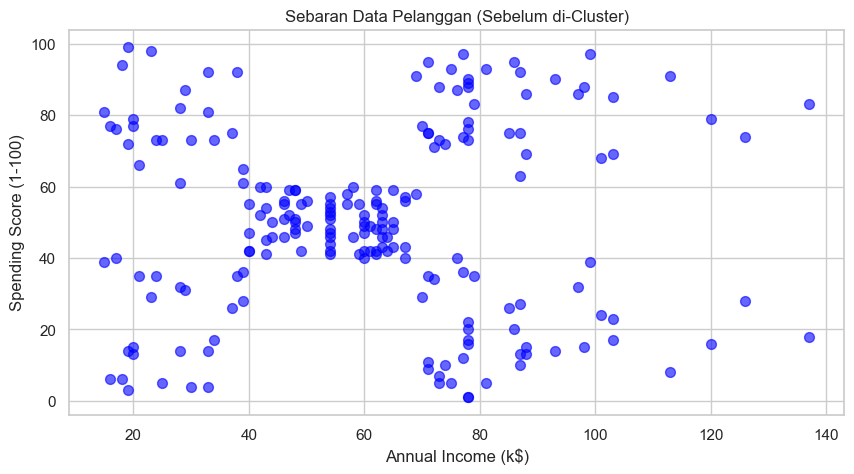

In [9]:
# Menggunakan Annual Income (k$) dan Spending Score (1-100)
X = df.iloc[:, [3, 4]].values

# Standarisasi Data 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Visualisasi sebaran data awal
plt.figure(figsize=(10, 5))
plt.scatter(X[:, 0], X[:, 1], s=50, color='blue', alpha=0.6)
plt.title('Sebaran Data Pelanggan (Sebelum di-Cluster)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

MENENTUKAN JUMLAH K DENGAN ELBOW METHOD

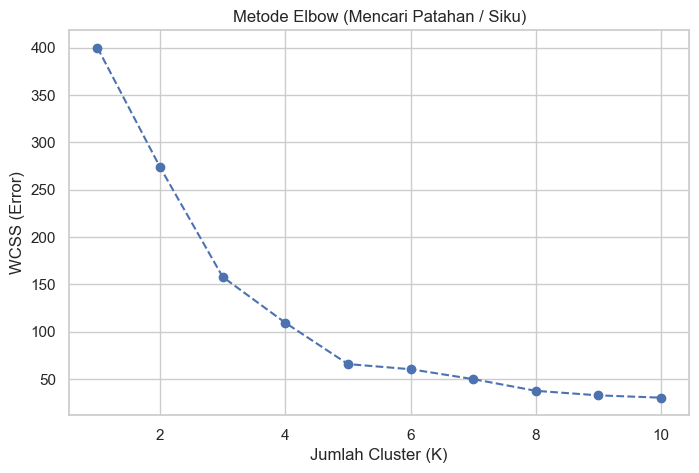

In [12]:
wcss = [] 

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled) 
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Metode Elbow (Mencari Patahan / Siku)')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS (Error)')
plt.show()

TRAINING MODEL K-MEANS

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Tambahkan hasil ke dataframe
df['Cluster'] = y_kmeans
print("\n--- Data dengan Label Cluster ---")
display(df.head())


--- Data dengan Label Cluster ---


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


EVALUASI MODEL CLUSTERING

In [14]:
# 1. Silhouette Score: Rentang -1 sampai 1. Mendekati 1 = Sangat Bagus.
# Mengukur seberapa mirip suatu data dengan clusternya sendiri dibanding cluster lain.
sil_score = silhouette_score(X_scaled, y_kmeans)

# 2. Davies-Bouldin Index: Semakin kecil nilainya (mendekati 0) = Semakin Bagus.
# Mengukur rasio jarak antar cluster dan penyebaran data di dalam cluster.
db_score = davies_bouldin_score(X_scaled, y_kmeans)

print("=== Laporan Evaluasi Clustering ===")
print(f"Silhouette Score      : {sil_score:.4f}")
print(f"Davies-Bouldin Index  : {db_score:.4f}")

=== Laporan Evaluasi Clustering ===
Silhouette Score      : 0.5547
Davies-Bouldin Index  : 0.5722


VISUALISASI HASIL AKHIR

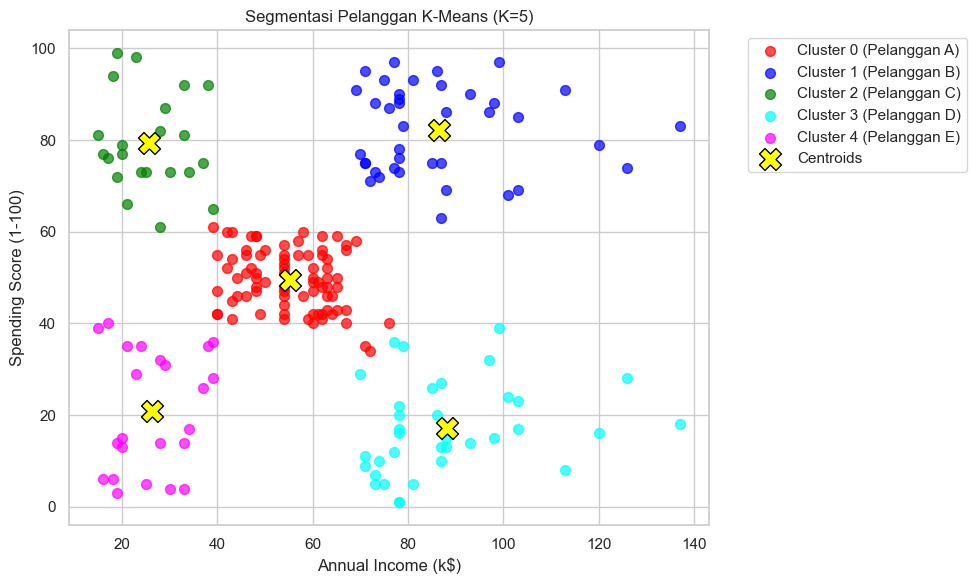

In [17]:
plt.figure(figsize=(10, 6))

colors = ['red', 'blue', 'green', 'cyan', 'magenta']
labels = ['Pelanggan A', 'Pelanggan B', 'Pelanggan C', 'Pelanggan D', 'Pelanggan E']

for i in range(5):
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1], 
                s=50, c=colors[i], label=f'Cluster {i} ({labels[i]})', alpha=0.7)

# Mengembalikan nilai centroid ke skala aslinya untuk di-plot
centroids_original_scale = scaler.inverse_transform(kmeans.cluster_centers_)

plt.scatter(centroids_original_scale[:, 0], centroids_original_scale[:, 1], 
            s=250, c='yellow', marker='X', edgecolors='black', label='Centroids')

plt.title('Segmentasi Pelanggan K-Means (K=5)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()